<a href="https://colab.research.google.com/github/mudather490/House_Price_model_linearregression/blob/main/House_Price_model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction

i will be building a house price prediction model using Python libraries such as `numpy`, `matplotlib`, and `scikit-learn`. Let's begin by importing the necessary libraries.

In [38]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Take the file path of my data

In [39]:
# Placeholder for data loading
path ='/content/drive/MyDrive/Datasate/MELBOURNE_HOUSE_PRICES_LESS.csv'
df = pd.read_csv(path)
display(df.head())

print("Please load your dataset in this cell.")

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Regionname,Propertycount,Distance,CouncilArea
0,Abbotsford,49 Lithgow St,3,h,1490000.0,S,Jellis,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
1,Abbotsford,59A Turner St,3,h,1220000.0,S,Marshall,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
2,Abbotsford,119B Yarra St,3,h,1420000.0,S,Nelson,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
3,Aberfeldie,68 Vida St,3,h,1515000.0,S,Barry,1/04/2017,3040,Western Metropolitan,1543,7.5,Moonee Valley City Council
4,Airport West,92 Clydesdale Rd,2,h,670000.0,S,Nelson,1/04/2017,3042,Western Metropolitan,3464,10.4,Moonee Valley City Council


Please load your dataset in this cell.


### Data Inspection and Cleaning
Before building the model, let me check for missing values and understand the data types.

In [40]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Basic statistics
display(df.describe())

Missing values in each column:
Suburb               0
Address              0
Rooms                0
Type                 0
Price            14590
Method               0
SellerG              0
Date                 0
Postcode             0
Regionname           0
Propertycount        0
Distance             0
CouncilArea          0
dtype: int64


,Rooms,Price,Postcode,Propertycount,Distance
count,63023.000000,4.843300e+04,63023.000000,63023.000000,63023.000000
mean,3.110595,9.978982e+05,3125.673897,7617.728131,12.684829
std,0.957551,5.934989e+05,125.626877,4424.423167,7.592015
min,1.000000,8.500000e+04,3000.000000,39.000000,0.000000
25%,3.000000,6.200000e+05,3056.000000,4380.000000,7.000000
50%,3.000000,8.300000e+05,3107.000000,6795.000000,11.400000
75%,4.000000,1.220000e+06,3163.000000,10412.000000,16.700000
max,31.000000,1.120000e+07,3980.000000,21650.000000,64.100000


For a basic linear regression, i would drop rows with missing 'Price' values and select numerical features.

In [41]:
import pandas as pd

# 1. Drop rows where Price is missing
df_clean = df.dropna(subset=['Price'])

# 2. Select more features, including categorical ones
# We'll use Suburb, Type, and Method as well as our numbers
categorical_features = ['Suburb', 'Type', 'Method', 'Regionname']
numerical_features = ['Rooms', 'Distance', 'Propertycount']

# 3. One-Hot Encoding: Convert text categories into numeric columns
X = pd.get_dummies(df_clean[categorical_features + numerical_features], columns=categorical_features)
y = df_clean['Price']

print(f"New data shape with encoded features: {X.shape}")
print("We went from 3 features to hundreds of specific 'clues'!")

New data shape with encoded features: (48433, 389)
We went from 3 features to hundreds of specific 'clues'!


In [42]:
corr = df.corr(numeric_only=True)

print(corr["Price"].sort_values(ascending=False))

Price            1.000000
Rooms            0.412438
Postcode         0.003112
Propertycount   -0.060769
Distance        -0.253668
Name: Price, dtype: float64


### 1. Split the Data
i split the data into a training set (to train the model) and a testing set (to evaluate its performance).

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 38746
Testing set size: 9687


### 2. Train the Model
i will initialize the Linear Regression model and fit it to our training data.

In [44]:
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Model training complete.")

Model training complete.


### 2.1 Interpret the Model
Let me look at the coefficients to understand how each feature impacts the price according to our Linear Regression model.

In [45]:
print(f"Intercept: {model.intercept_:,.2f}\n")

# We use X.columns because 'features' was not defined,
# and X.columns contains all 389 encoded feature names.
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:,.2f}")

print("\nInterpretation:")
# model.coef_[0] corresponds to the first column in X, which is 'Rooms'
print(f"For every additional room, the price increases by approximately ${model.coef_[0]:,.0f}.")

Intercept: 523,636.12

Rooms: 238,395.23
Distance: -28,310.53
Propertycount: -3.06
Suburb_Abbotsford: 133,583.30
Suburb_Aberfeldie: 479,868.24
Suburb_Airport West: 50,203.22
Suburb_Albanvale: -251,685.56
Suburb_Albert Park: 366,430.69
Suburb_Albion: -20,671.69
Suburb_Alphington: 364,081.07
Suburb_Altona: 192,916.24
Suburb_Altona Meadows: -85,539.72
Suburb_Altona North: -66,408.68
Suburb_Ardeer: -153,272.19
Suburb_Armadale: 362,866.90
Suburb_Ascot Vale: 185,922.63
Suburb_Ashburton: 84,043.56
Suburb_Ashwood: -267,145.53
Suburb_Aspendale: 163,670.04
Suburb_Aspendale Gardens: -96,112.78
Suburb_Attwood: -273,052.12
Suburb_Avondale Heights: -26,794.41
Suburb_Bacchus Marsh: 193,021.03
Suburb_Balaclava: -287,575.43
Suburb_Balwyn: 389,965.30
Suburb_Balwyn North: 139,210.43
Suburb_Bayswater: 51,369.40
Suburb_Bayswater North: -91,135.41
Suburb_Beaconsfield: 15,529.34
Suburb_Beaconsfield Upper: 230.75
Suburb_Beaumaris: 176,834.92
Suburb_Belgrave: -200,609.76
Suburb_Belgrave Heights: -509,256.43
Su

### 3. Evaluate and Visualize
i well see the error metrics and plot the regression line against our test data.

Mean Squared Error: 121211553932.57
R^2 Score: 0.6462


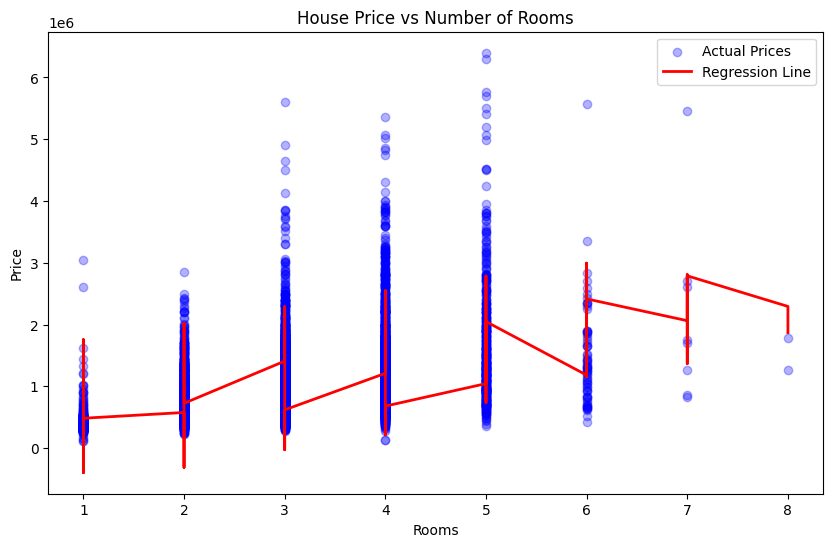

In [46]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.4f}")

# Visualization - Improved sorting
plt.figure(figsize=(10, 6))

# 1. Scatter plot of actual data
plt.scatter(X_test['Rooms'], y_test, color='blue', alpha=0.3, label='Actual Prices')

# 2. Sort the test data for a smooth regression line
sorted_index = X_test['Rooms'].argsort()
X_sorted = X_test['Rooms'].iloc[sorted_index]
y_pred_sorted = y_pred[sorted_index]

# 3. Plot the regression line
plt.plot(X_sorted, y_pred_sorted, color='red', linewidth=2, label='Regression Line')

plt.title('House Price vs Number of Rooms')
plt.xlabel('Rooms')
plt.ylabel('Price')
plt.legend()
plt.show()

### 3. Final Model Performance
I'm using Linear Regression with all features (Rooms, Distance, Suburb, etc.) to get the most accurate predictions possible.

In [47]:
# We have already trained the 'model' variable using LinearRegression in the previous cells.
# Let's confirm its performance on the test set.
y_final_pred = model.predict(X_test)
final_r2 = r2_score(y_test, y_final_pred)

print(f"Final Linear Regression R^2 Score: {final_r2:.4f}")

Final Linear Regression R^2 Score: 0.6462


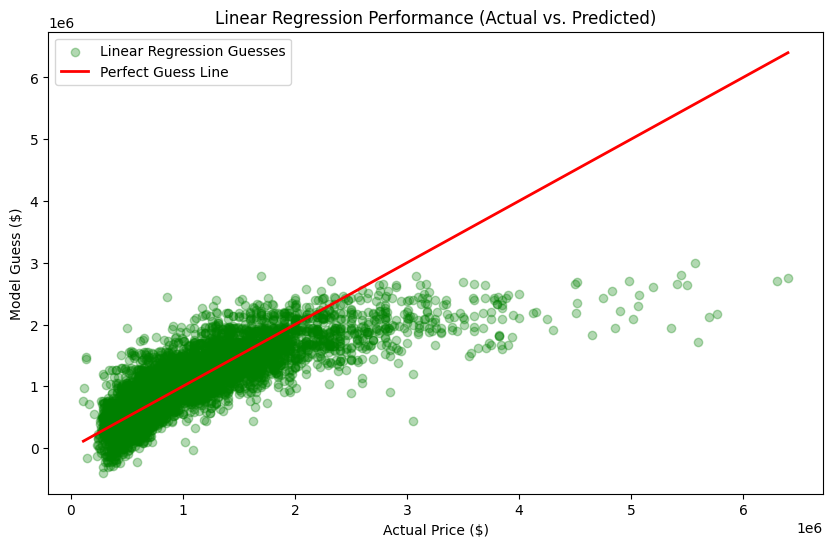

In [48]:
plt.figure(figsize=(10, 6))

# Plotting the actual vs predicted values for Linear Regression
plt.scatter(y_test, y_pred, color='green', alpha=0.3, label='Linear Regression Guesses')

# A diagonal line represents a perfect guess
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', lw=2, label='Perfect Guess Line')

plt.title('Linear Regression Performance (Actual vs. Predicted)')

plt.xlabel('Actual Price ($)')
plt.ylabel('Model Guess ($)')

plt.legend()
plt.show()

### 4. Save and Test the Model
A professional workflow involves saving the model so it can be used later without retraining.

In [49]:
# 1. Save the Linear Regression model
joblib.dump(model, "house_price_model.pkl")
print("Linear Regression model saved to house_price_model.pkl")

# 2. Test it using a real row from our test data
# We must use a row from X_test because it contains all 389 encoded features
sample_row = X_test.iloc[[0]]
prediction = model.predict(sample_row)

print(f"\nPrediction for house at index 0: ${prediction[0]:,.2f}")
print(f"Actual price: ${y_test.iloc[0]:,.2f}")

Linear Regression model saved to house_price_model.pkl

Prediction for house at index 0: $1,046,326.08
Actual price: $885,000.00


### Step-by-Step: How to use your saved model

1. **Ensure the file exists**: You should see `house_price_model.pkl` in your current directory.
2. **Import joblib**: This is the tool that reads the saved file.
3. **Load the model**: `model = joblib.load('filename.pkl')`.
4. **Prepare Input**: The model expects a list of lists (a 2D array) where the columns are exactly `['Rooms', 'Distance', 'Propertycount']`.

**Note:** If i  close Colab, files in the temporary folder are deleted. For permanent storage, connect to Google Drive using `from google.colab import drive; drive.mount('/content/drive')` and save the file there.

In [50]:
import joblib
import pandas as pd

# 1. Load the model
my_model = joblib.load('house_price_model.pkl')

# 2. To predict, we must provide ALL 389 features used during training.
# The easiest way to test is to use a row from X_test that already has the correct format.
sample_house = X_test.iloc[[0]]

# 3. Get the prediction
predicted_price = my_model.predict(sample_house)

print(f"Predicted Market Value: ${predicted_price[0]:,.2f}")
print(f"Actual Price was: ${y_test.iloc[0]:,.2f}")

Predicted Market Value: $1,046,326.08
Actual Price was: $885,000.00


### To Running your model in PyCharm or a Local Script

Afte downloaded `house_price_model.pkl`, you can use this standalone script in PyCharm to make predictions:

### Making a Custom Prediction
To predict for a house that isn't in my dataset, i must ensure the input matches the 389 columns the model expects.

In [52]:
def make_custom_prediction(suburb, house_type, method, region, rooms, distance, count):
    # 1. Create a row of zeros with the correct column names
    input_data = pd.DataFrame(0, index=[0], columns=X.columns)

    # 2. Fill numerical values
    input_data['Rooms'] = rooms
    input_data['Distance'] = distance
    input_data['Propertycount'] = count

    # 3. Fill categorical values (One-Hot Encoding)
    # We construct the column names based on the training format (e.g., 'Suburb_Abbotsford')
    cols_to_set = [
        f'Suburb_{suburb}',
        f'Type_{house_type}',
        f'Method_{method}',
        f'Regionname_{region}'
    ]

    for col in cols_to_set:
        if col in input_data.columns:
            input_data[col] = 1

    # 4. Predict
    prediction = model.predict(input_data)
    return prediction[0]

# Example usage:
price = make_custom_prediction(
    suburb='Abbotsford',
    house_type='h',
    method='S',
    region='Northern Metropolitan',
    rooms=3,
    distance=5.0,
    count=4000
)

print(f"Predicted Price: ${price:,.2f}")

Predicted Price: $1,296,430.66
